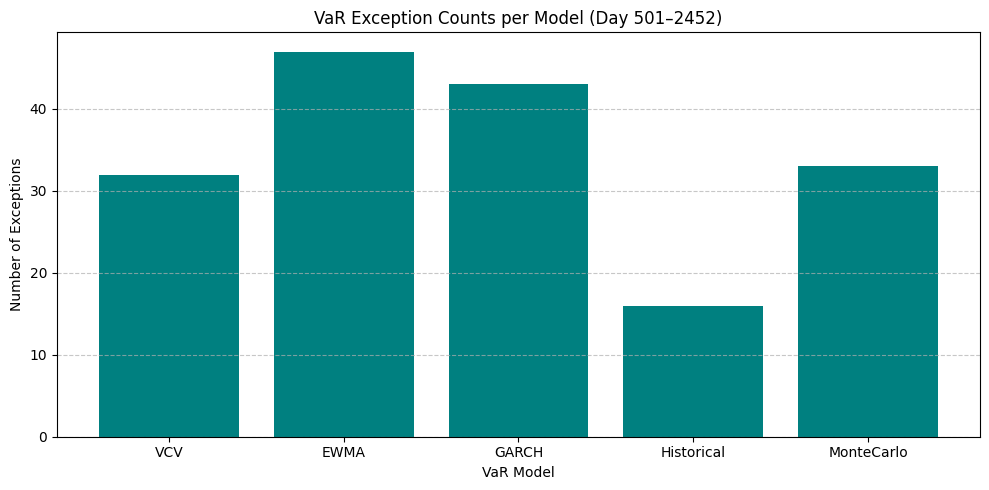

,Model,Total Observations,Exceptions,Exception Rate (%)
0,VCV,2452,32,1.305
1,EWMA,2452,47,1.917
2,GARCH,2452,43,1.754
3,Historical,1952,16,0.820
4,MonteCarlo,1952,33,1.691


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Step 1: Define base path
base_path = "datamaster_project2"
backtest_path = os.path.join(base_path, "backtesting2")
os.makedirs(backtest_path, exist_ok=True)

# Step 2: Define function to load .csv files
def load_var_csv(path, var_column):
    df = pd.read_csv(os.path.join(base_path, path), parse_dates=['Date'])
    df = df[['Date', 'Log_Returns', var_column]].dropna()
    df.set_index('Date', inplace=True)
    return df.rename(columns={var_column: 'VaR'})

# Step 3: File mapping for all models
models = {
    'VCV': ('1_Variance_Covariance_Method/nifty50_returns_with_var_vcv.csv', 'VaR_VCV'),
    'EWMA': ('2_EWMA_Method/nifty50_returns_with_var_ewma.csv', 'VaR_EWMA'),
    'GARCH': ('3_GARCH_Method/nifty50_returns_with_var_garch.csv', 'VaR_GARCH'),
    'Historical': ('4_Historical_Method/nifty50_returns_with_var_historical.csv', 'VaR_HIST'),
    'MonteCarlo': ('5_MonteCarlo_Method/nifty50_returns_with_var_mc.csv', 'VaR_MC'),
}

# Step 4: Exception computation
exception_summary = []

for model, (file_path, var_column) in models.items():
    df = load_var_csv(file_path, var_column)
    df = df.loc[df.index >= df.index[0]]  # already aligned from Day 501 onward
    df['Exception'] = df['Log_Returns'] < df['VaR']
    total_obs = len(df)
    total_exceptions = df['Exception'].sum()
    exception_rate = (total_exceptions / total_obs) * 100

    exception_summary.append({
        'Model': model,
        'Total Observations': total_obs,
        'Exceptions': int(total_exceptions),
        'Exception Rate (%)': round(exception_rate, 3)
    })

# Step 5: Save summary
summary_df = pd.DataFrame(exception_summary)
summary_df.to_csv(os.path.join(backtest_path, 'exception_summary.csv'), index=False)
summary_df.to_excel(os.path.join(backtest_path, 'exception_summary.xlsx'), index=False)

# Step 6: Plot
plt.figure(figsize=(10, 5))
plt.bar(summary_df['Model'], summary_df['Exceptions'], color='teal')
plt.title('VaR Exception Counts per Model (Day 501–2452)')
plt.xlabel('VaR Model')
plt.ylabel('Number of Exceptions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(backtest_path, 'exception_bar_plot.png'), dpi=300)
plt.show()

# Step 7: Show result in notebook
summary_df



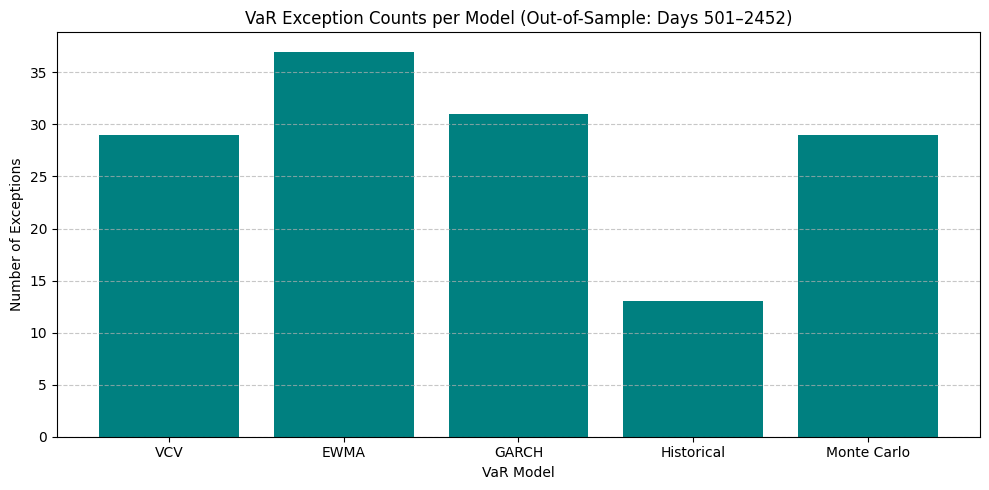

,Model,Total Observations,Exceptions,Exception Rate (%)
0,VCV,1952,29,1.486
1,EWMA,1952,37,1.895
2,GARCH,1952,31,1.588
3,Historical,1452,13,0.895
4,Monte Carlo,1452,29,1.997


In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Step 1: Define base path
base_path = "datamaster_project2"
backtest_path = os.path.join(base_path, "backtesting3")
os.makedirs(backtest_path, exist_ok=True)

# Step 2: Define function to load and trim .csv files
def load_var_csv(path, var_column):
    df = pd.read_csv(os.path.join(base_path, path), parse_dates=['Date'])
    df = df[['Date', 'Log_Returns', var_column]].dropna()
    df.set_index('Date', inplace=True)
    df = df.iloc[500:]  # Start from Day 501 — global standard for rolling forecast
    return df.rename(columns={var_column: 'VaR'})

# Step 3: File mapping for all models
models = {
    'VCV': ('1_Variance_Covariance_Method/nifty50_returns_with_var_vcv.csv', 'VaR_VCV'),
    'EWMA': ('2_EWMA_Method/nifty50_returns_with_var_ewma.csv', 'VaR_EWMA'),
    'GARCH': ('3_GARCH_Method/nifty50_returns_with_var_garch.csv', 'VaR_GARCH'),
    'Historical': ('4_Historical_Method/nifty50_returns_with_var_historical.csv', 'VaR_HIST'),
    'Monte Carlo': ('5_MonteCarlo_Method/nifty50_returns_with_var_mc.csv', 'VaR_MC'),
}

# Step 4: Exception computation
exception_summary = []

for model, (file_path, var_column) in models.items():
    df = load_var_csv(file_path, var_column)
    df['Exception'] = df['Log_Returns'] < df['VaR']
    total_obs = len(df)
    total_exceptions = df['Exception'].sum()
    exception_rate = (total_exceptions / total_obs) * 100

    exception_summary.append({
        'Model': model,
        'Total Observations': total_obs,
        'Exceptions': int(total_exceptions),
        'Exception Rate (%)': round(exception_rate, 3)
    })

# Step 5: Save summary
summary_df = pd.DataFrame(exception_summary)
summary_df.to_csv(os.path.join(backtest_path, 'exception_summary.csv'), index=False)
summary_df.to_excel(os.path.join(backtest_path, 'exception_summary.xlsx'), index=False)

# Step 6: Plot
plt.figure(figsize=(10, 5))
plt.bar(summary_df['Model'], summary_df['Exceptions'], color='teal')
plt.title('VaR Exception Counts per Model (Out-of-Sample: Days 501–2452)')
plt.xlabel('VaR Model')
plt.ylabel('Number of Exceptions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(backtest_path, 'exception_bar_plot.png'), dpi=300)
plt.show()

# Step 7: Display in notebook
summary_df


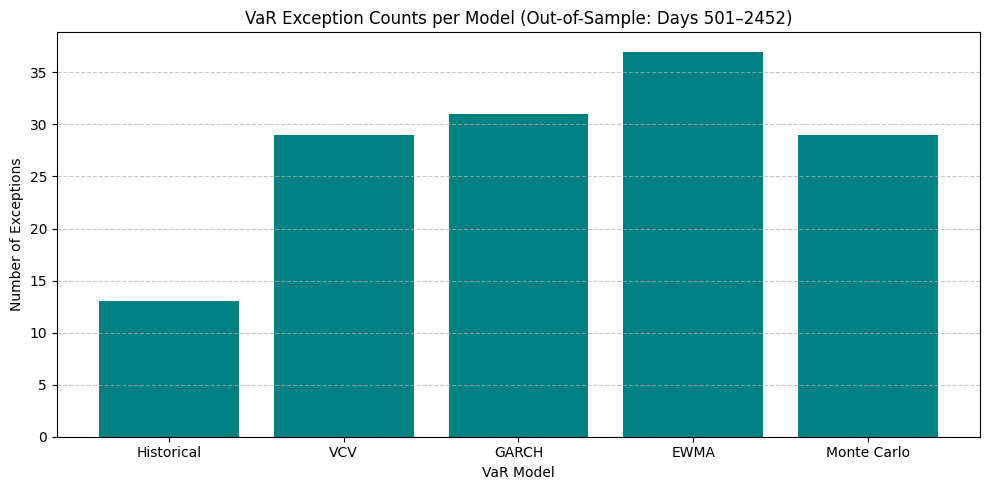

,Model,Total Observations,Expected Exceptions (1%),Exceptions,Misses vs Expected,Exception Rate (%)
0,Historical,1452,14.5,13,-1,0.895
1,VCV,1952,19.5,29,9,1.486
2,GARCH,1952,19.5,31,11,1.588
3,EWMA,1952,19.5,37,17,1.895
4,Monte Carlo,1452,14.5,29,14,1.997


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Set base and output path
base_path = "datamaster_project2"
backtest_path = os.path.join(base_path, "backtesting4")
os.makedirs(backtest_path, exist_ok=True)

# Model input files and columns
models = {
    'VCV': ('1_Variance_Covariance_Method/nifty50_returns_with_var_vcv.csv', 'VaR_VCV'),
    'EWMA': ('2_EWMA_Method/nifty50_returns_with_var_ewma.csv', 'VaR_EWMA'),
    'GARCH': ('3_GARCH_Method/nifty50_returns_with_var_garch.csv', 'VaR_GARCH'),
    'Historical': ('4_Historical_Method/nifty50_returns_with_var_historical.csv', 'VaR_HIST'),
    'Monte Carlo': ('5_MonteCarlo_Method/nifty50_returns_with_var_mc.csv', 'VaR_MC')
}

# Function to load and align data
def load_var_csv(path, var_column):
    df = pd.read_csv(os.path.join(base_path, path), parse_dates=['Date'])
    df = df[['Date', 'Log_Returns', var_column]].dropna()
    df.set_index('Date', inplace=True)
    df.rename(columns={var_column: 'VaR'}, inplace=True)
    return df.iloc[500:]  # Day 501 onwards (out-of-sample)

# Compute exceptions
summary = []
for model, (path, var_col) in models.items():
    df = load_var_csv(path, var_col)
    df['Exception'] = df['Log_Returns'] < df['VaR']
    total_obs = len(df)
    exceptions = df['Exception'].sum()
    expected = round(0.01 * total_obs, 1)
    summary.append({
        'Model': model,
        'Total Observations': total_obs,
        'Expected Exceptions (1%)': expected,
        'Exceptions': int(exceptions),
        'Misses vs Expected': int(exceptions - expected),
        'Exception Rate (%)': round(100 * exceptions / total_obs, 3)
    })

# Create DataFrame and save
summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by='Exception Rate (%)').reset_index(drop=True)
summary_df.to_csv(os.path.join(backtest_path, "exception_summary.csv"), index=False)
summary_df.to_excel(os.path.join(backtest_path, "exception_summary.xlsx"), index=False)

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(summary_df['Model'], summary_df['Exceptions'], color='teal')
plt.title('VaR Exception Counts per Model (Out-of-Sample: Days 501–2452)')
plt.xlabel('VaR Model')
plt.ylabel('Number of Exceptions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(backtest_path, 'exception_bar_plot.png'), dpi=300)
plt.show()

# Show in notebook
summary_df


In [7]:
import pandas as pd
import os

# Base directory
base_path = "datamaster_project2"

# Helper to load and prepare a VaR CSV
def load_var_csv(rel_path, var_col):
    df = pd.read_csv(
        os.path.join(base_path, rel_path),
        parse_dates=['Date']
    ).set_index('Date')
    return df[['Log_Returns', var_col]].rename(columns={var_col: 'VaR'}).sort_index()

# 1) Load the first three models and drop the first 500 in-sample days
first_group = {
    'VCV':       ('1_Variance_Covariance_Method/nifty50_returns_with_var_vcv.csv', 'VaR_VCV'),
    'EWMA':      ('2_EWMA_Method/nifty50_returns_with_var_ewma.csv',      'VaR_EWMA'),
    'GARCH':     ('3_GARCH_Method/nifty50_returns_with_var_garch.csv',    'VaR_GARCH'),
}

dfs_first = {}
for name, (path, col) in first_group.items():
    df = load_var_csv(path, col)
    dfs_first[name] = df.iloc[500:]   # drop first 500 days

# 2) Load the remaining two models (already out-of-sample)
second_group = {
    'Historical':  ('4_Historical_Method/nifty50_returns_with_var_historical.csv', 'VaR_HIST'),
    'MonteCarlo':  ('5_MonteCarlo_Method/nifty50_returns_with_var_mc.csv',        'VaR_MC'),
}

dfs_second = {}
for name, (path, col) in second_group.items():
    dfs_second[name] = load_var_csv(path, col)

# 3) Compare lengths and date ranges
print("=== First Group ===")
for name, df in dfs_first.items():
    print(f"{name:12s} → rows: {len(df):4d}, start: {df.index[0].date()}, end: {df.index[-1].date()}")

print("\n=== Second Group ===")
for name, df in dfs_second.items():
    print(f"{name:12s} → rows: {len(df):4d}, start: {df.index[0].date()}, end: {df.index[-1].date()}")

# 4) Check if all models now share the same index
all_indices = [df.index for df in list(dfs_first.values()) + list(dfs_second.values())]
common = all(idx.equals(all_indices[0]) for idx in all_indices[1:])
print(f"\nAll models aligned on same dates? {'YES' if common else 'NO'}")


=== First Group ===
VCV          → rows: 1952, start: 2016-01-28, end: 2023-12-29
EWMA         → rows: 1952, start: 2016-01-28, end: 2023-12-29
GARCH        → rows: 1952, start: 2016-01-28, end: 2023-12-29

=== Second Group ===
Historical   → rows: 1952, start: 2016-01-28, end: 2023-12-29
MonteCarlo   → rows: 1952, start: 2016-01-28, end: 2023-12-29

All models aligned on same dates? YES


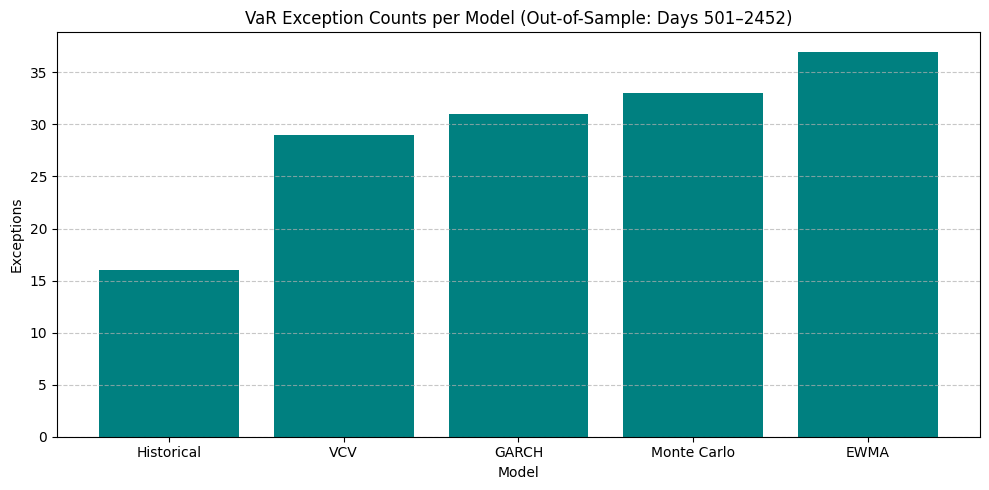

,Model,Total Observations,Exceptions,Exception Rate (%)
0,Historical,1952,16,0.820
1,VCV,1952,29,1.486
2,GARCH,1952,31,1.588
3,Monte Carlo,1952,33,1.691
4,EWMA,1952,37,1.895


In [9]:
import os, glob
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup paths
base_path    = "datamaster_project2"
backtest_dir = os.path.join(base_path, "backtesting_final")
os.makedirs(backtest_dir, exist_ok=True)

# 2. Discover all VaR CSVs
all_csvs = glob.glob(os.path.join(base_path, "**", "nifty50_returns_with_var_*.csv"), recursive=True)

# 3. Map filenames to model keys
model_files = {}
for fp in all_csvs:
    fname = os.path.basename(fp).lower()
    if "var_vcv" in fname:
        model_files["VCV"] = fp
    elif "var_ewma" in fname:
        model_files["EWMA"] = fp
    elif "var_garch" in fname:
        model_files["GARCH"] = fp
    elif "var_hist" in fname:
        model_files["Historical"] = fp
    elif "var_mc" in fname or "var_montecarlo" in fname:
        model_files["Monte Carlo"] = fp

# Sanity check
assert set(model_files) == {"VCV","EWMA","GARCH","Historical","Monte Carlo"}, "Missing or extra files!"

# 4. Load, align, and trim
dfs = {}
for name, fp in model_files.items():
    df = pd.read_csv(fp, parse_dates=["Date"])
    df = df[["Date","Log_Returns"] + [c for c in df.columns if c.lower().startswith("var_")]]
    df = df.dropna().set_index("Date").sort_index()
    # rename the VaR column to a generic name
    var_col = [c for c in df.columns if c.startswith("VaR")][0]
    df = df.rename(columns={var_col: "VaR"})
    # drop first 500 days only for the first three models
    if name in {"VCV","EWMA","GARCH"}:
        df = df.iloc[500:]
    dfs[name] = df

# 5. Verify alignment
idx0 = dfs["VCV"].index
for name, df in dfs.items():
    assert df.index.equals(idx0), f"Index mismatch for {name}"

# 6. Exception analysis
records = []
for name, df in dfs.items():
    total_obs = len(df)
    exceptions = int((df["Log_Returns"] < df["VaR"]).sum())
    exc_rate  = round(100 * exceptions / total_obs, 3)
    records.append({
        "Model": name,
        "Total Observations": total_obs,
        "Exceptions": exceptions,
        "Exception Rate (%)": exc_rate
    })

summary_df = pd.DataFrame(records).sort_values("Exception Rate (%)").reset_index(drop=True)

# 7. Save outputs
summary_df.to_csv(os.path.join(backtest_dir, "exception_summary.csv"), index=False)
summary_df.to_excel(os.path.join(backtest_dir, "exception_summary.xlsx"), index=False)

# 8. Plot
plt.figure(figsize=(10,5))
plt.bar(summary_df["Model"], summary_df["Exceptions"], color="teal")
plt.title("VaR Exception Counts per Model (Out-of-Sample: Days 501–2452)")
plt.xlabel("Model")
plt.ylabel("Exceptions")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(backtest_dir, "exception_bar_plot.png"), dpi=300)
plt.show()

# 9. Display summary
summary_df


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2, norm

# === Step 1: Load Your Final Exception Summary ===
df = pd.read_csv("datamaster_project2/backtesting_final/exception_summary.csv")

# === Step 2: Define Constants ===
T = 1952        # Total number of forecasted days (rolling window)
p = 0.01        # Expected exception probability under 99% VaR

# === Step 3: Initialize Results Container ===
results = []

for index, row in df.iterrows():
    model = row['Model']
    x = int(row['Exceptions'])  # Observed exceptions
    p_hat = x / T               # Observed exception rate

    # --- Kupiec POF Test ---
    if x == 0:
        kupiec_pval = 1.0  # log(0) protection
    else:
        LR_pof = -2 * np.log(((1 - p_hat) ** (T - x)) * (p_hat ** x)) + \
                 2 * np.log(((1 - p) ** (T - x)) * (p ** x))
        kupiec_pval = 1 - chi2.cdf(LR_pof, df=1)

    kupiec_verdict = "Reject" if kupiec_pval < 0.05 else "Accept"

    # --- Binomial Z-Test ---
    z_stat = (x - T * p) / np.sqrt(T * p * (1 - p))
    z_pval = 2 * (1 - norm.cdf(abs(z_stat)))
    z_verdict = "Reject" if z_pval < 0.05 else "Accept"

    # --- Store Results ---
    results.append({
        "Model": model,
        "Exceptions": x,
        "Expected Exceptions": round(T * p, 2),
        "Exception Rate (%)": round(100 * p_hat, 3),
        "Kupiec p-value": round(kupiec_pval, 5),
        "Kupiec Verdict": kupiec_verdict,
        "Z-Test p-value": round(z_pval, 5),
        "Z-Test Verdict": z_verdict
    })

# === Step 4: Create Final Table ===
results_df = pd.DataFrame(results)

# === Step 5: Save Outputs ===
results_df.to_csv("datamaster_project2/backtesting_final/statistical_evaluation.csv", index=False)
results_df.to_excel("datamaster_project2/backtesting_final/statistical_evaluation.xlsx", index=False)

# === Step 6: Optional: Display the Table ===
print(results_df)


         Model  Exceptions  Expected Exceptions  Exception Rate (%)  \
0   Historical          16                19.52               0.820   
1          VCV          29                19.52               1.486   
2        GARCH          31                19.52               1.588   
3  Monte Carlo          33                19.52               1.691   
4         EWMA          37                19.52               1.895   

   Kupiec p-value Kupiec Verdict  Z-Test p-value Z-Test Verdict  
0             1.0         Accept         0.42329         Accept  
1             1.0         Accept         0.03104         Reject  
2             1.0         Accept         0.00902         Reject  
3             1.0         Accept         0.00217         Reject  
4             1.0         Accept         0.00007         Reject  


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import chi2, norm

# Load your data
df = pd.read_csv("datamaster_project2/backtesting_final/exception_summary.csv")

# Constants
T = 1952  # total observations
p = 0.01  # expected exception probability

# Container for results
results = []

for index, row in df.iterrows():
    model = row['Model']
    x = int(row['Exceptions'])
    p_hat = x / T

    # Corrected Kupiec POF Test (industry-standard formula)
    if x == 0 or x == T:
        LR_pof = 0  # special cases handling
    else:
        LR_pof = -2 * (np.log(((1 - p) ** (T - x)) * (p ** x))) + \
                  2 * (np.log(((1 - p_hat) ** (T - x)) * (p_hat ** x)))

    kupiec_pval = 1 - chi2.cdf(LR_pof, df=1)
    kupiec_verdict = "Reject" if kupiec_pval < 0.05 else "Accept"

    # Binomial Z-Test (unchanged and correct)
    z_stat = (x - T * p) / np.sqrt(T * p * (1 - p))
    z_pval = 2 * (1 - norm.cdf(abs(z_stat)))
    z_verdict = "Reject" if z_pval < 0.05 else "Accept"

    results.append({
        "Model": model,
        "Exceptions": x,
        "Expected Exceptions": round(T * p, 2),
        "Exception Rate (%)": round(100 * p_hat, 3),
        "Kupiec LR": round(LR_pof, 4),
        "Kupiec p-value": round(kupiec_pval, 5),
        "Kupiec Verdict": kupiec_verdict,
        "Z-Test statistic": round(z_stat, 4),
        "Z-Test p-value": round(z_pval, 5),
        "Z-Test Verdict": z_verdict
    })

# Create a DataFrame and save results
results_df = pd.DataFrame(results)
results_df.to_csv("datamaster_project2/backtesting_final/statistical_evaluation_corrected.csv", index=False)
results_df.to_excel("datamaster_project2/backtesting_final/statistical_evaluation_corrected.xlsx", index=False)

# Display results
print(results_df)


         Model  Exceptions  Expected Exceptions  Exception Rate (%)  \
0   Historical          16                19.52               0.820   
1          VCV          29                19.52               1.486   
2        GARCH          31                19.52               1.588   
3  Monte Carlo          33                19.52               1.691   
4         EWMA          37                19.52               1.895   

   Kupiec LR  Kupiec p-value Kupiec Verdict  Z-Test statistic  Z-Test p-value  \
0     0.6832         0.40849         Accept           -0.8007         0.42329   
1     4.0462         0.04427         Reject            2.1565         0.03104   
2     5.7863         0.01615         Reject            2.6115         0.00902   
3     7.7887         0.00526         Reject            3.0664         0.00217   
4    12.5200         0.00040         Reject            3.9763         0.00007   

  Z-Test Verdict  
0         Accept  
1         Reject  
2         Reject  
3         